In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

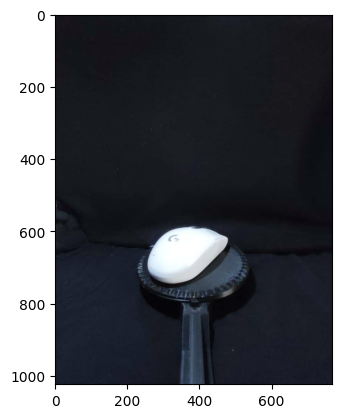

In [12]:
img_gray = []
img_color = []
for i in range(1,12):
  img_path = "raton"+str(i)+".jpeg"
  img = cv.imread(img_path)
  if img is None:
    print(f"No se pudo cargar la imagen {img_path}")
    continue
  img_color.append(img)
  img_gray.append(cv.cvtColor(img, cv.COLOR_BGR2GRAY))

if img_color:
  plt.imshow(img_color[0])
else:
  print("No se cargó ninguna imagen")

In [13]:
imgs_clean = []
for i in range(11):

  img_blur = cv.medianBlur(img_gray[i], 5)

  _, bin = cv.threshold(img_blur, 140, 255, cv.THRESH_BINARY)

  SE = cv.getStructuringElement(cv.MORPH_ELLIPSE, (35,35))
  bin_open = cv.dilate(bin, SE)

  clean = cv.bitwise_and(img_gray[i],img_gray[i], mask=bin_open)
  imgs_clean.append(clean)
  cv.imwrite('raton_clean'+str(i)+'.jpg', clean)

In [14]:
def feature_and_matching_knn_test(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.knnMatch(des1, des2, k=2)
  #Escogemos sólo las asociaciones de puntos cercanos
  good_matches = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)

  #Medimos rendimiento
  img_matched = cv.drawMatches(im1, kp1, im2, kp2, good_matches, None, matchColor=(0, 255, 0),
                       singlePointColor=(0, 255, 0), flags=2)
  plt.imshow(img_matched)
  plt.axis('off')
  print(f"Puntos encontrados img1: {len(kp1)}")
  print(f"Puntos encontrados img2: {len(kp2)}")
  print(f"Buenos emparejamientos (Matches): {len(good_matches)}")


In [15]:
def feature_and_matching(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.match(des1, des2)
  #Escogemos sólo las asociaciones de puntos cercanos
  '''  
  matches = bf.knnmatch(des1, des2)
  good_matches = []
  pts1 = []
  pts2 = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)
      pts1.append(kp1[m.queryIdx].pt)
      pts2.append(kp2[m.trainIdx].pt)
  '''
  pts1 = np.int32([kp1[p.queryIdx].pt for p in matches]).reshape(-1, 1, 2)
  pts2 = np.int32([kp2[p.trainIdx].pt for p in matches]).reshape(-1, 1, 2)
  return (pts1, pts2)


Caso 0,1
Puntos encontrados img1: 51
Puntos encontrados img2: 47
Buenos emparejamientos (Matches): 9
Caso 1,2
Puntos encontrados img1: 47
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 5
Caso 2,3
Puntos encontrados img1: 57
Puntos encontrados img2: 51
Buenos emparejamientos (Matches): 3
Caso 3,4
Puntos encontrados img1: 51
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 3
Caso 4,5
Puntos encontrados img1: 57
Puntos encontrados img2: 68
Buenos emparejamientos (Matches): 4
Caso 5,6
Puntos encontrados img1: 68
Puntos encontrados img2: 82
Buenos emparejamientos (Matches): 5
Caso 6,7
Puntos encontrados img1: 82
Puntos encontrados img2: 65
Buenos emparejamientos (Matches): 13
Caso 7,8
Puntos encontrados img1: 65
Puntos encontrados img2: 66
Buenos emparejamientos (Matches): 4
Caso 8,9
Puntos encontrados img1: 66
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 8
Caso 9,10
Puntos encontrados img1: 57
Puntos encontrados img2: 48
Buenos emparejamientos (

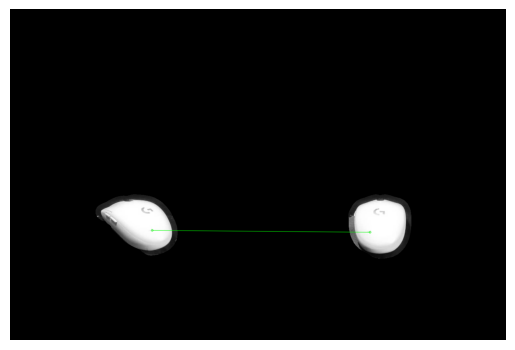

In [16]:
for i,j in zip(range(10),range(1,11)):
  print(f'Caso {i},{j}')
  feature_and_matching_knn_test(imgs_clean[i], imgs_clean[j])


In [17]:
def drawlines(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r,c= img1.shape
    img1 = cv.cvtColor(img1,cv.COLOR_GRAY2BGR)
    img2 = cv.cvtColor(img2,cv.COLOR_GRAY2BGR)
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        img1 = cv.line(img1, (x0,y0), (x1,y1), color,1)
        img1 = cv.circle(img1,tuple(pt1[0]),5,color,-1)
        img2 = cv.circle(img2,tuple(pt2[0]),5,color,-1)
    return img1,img2

def Sfm_test(im1,im2):
    pts1, pts2 = feature_and_matching(im1, im2)
    F = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC)[0]

    lines1 = cv.computeCorrespondEpilines(pts2.reshape(-1,1,2), 2, F)
    lines1 = lines1.reshape(-1,3)
    im3, im4 =drawlines(im1, im2, lines1, pts1, pts2)


    lines2 = cv.computeCorrespondEpilines(pts1.reshape(-1,1,2), 1, F)
    lines2 = lines2.reshape(-1,3)
    im5,im6 = drawlines(im2,im1,lines2,pts2,pts1)

    final_frame = cv.hconcat((im5, im3))
    plt.imshow(final_frame)
    plt.axis('off')

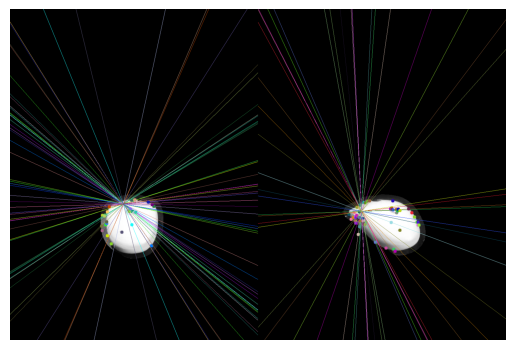

In [18]:

Sfm_test(imgs_clean[9], imgs_clean[10])

In [85]:

def Sfm(im1, im2, focal_length=20):
    pts1, pts2 = feature_and_matching(im1, im2)
    h, w = im1.shape[:2]
    if focal_length == 0:
        focal_length = np.maximum(h, w)  # Aproximación común si se desconoce 
    pixel_length = 0.05
    cx, cy = w / 2, h / 2
    K = np.array([[(focal_length/pixel_length), 0, cx],
                  [0, (focal_length/pixel_length), cy],
                  [0, 0, 1]])
    '''
    F = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC)[0]
    E = K.T.dot(F.dot(K))
    '''
    E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.999, threshold=1.0)
    

    pts1 = pts1[mask.ravel() == 1]
    pts2 = pts2[mask.ravel() == 1]


    _, R, t, mask_pose = cv.recoverPose(E, pts1, pts2, K)


    P1 = np.hstack((np.eye(3), np.zeros((3, 1))))
    P1 = K @ P1  # P1 = K[I|0]
    

    P2 = np.hstack((R, t))
    P2 = K @ P2  


    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)
    pts3d = pts4d[:3] / pts4d[3]
    print(pts3d.T[:,0,:].shape)
    return (pts3d.T[:,0,:]).copy()
Sfm(imgs_clean[0], imgs_clean[1])


(15, 3)


/tmp/ipykernel_13185/1219434575.py:34: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_13185/1219434575.py:34: RuntimeWarning:

invalid value encountered in divide



array([[ 0.59671379, -2.79178971,  0.01078409],
       [-1.00348822, -1.00518783,  0.99957319],
       [ 1.40381711,  1.        ,  0.        ],
       [        inf,         nan,         inf],
       [ 0.09102008,  1.        ,  0.        ],
       [        inf,         nan,         inf],
       [-1.93597193,  1.        ,  0.        ],
       [        inf,         nan,         inf],
       [-0.28998355,  1.        ,  0.        ],
       [        inf,         nan,         inf],
       [ 1.96921195,  1.        ,  0.        ],
       [        inf,         nan,         inf],
       [ 0.        ,  1.        ,  0.        ],
       [        inf,         nan,         inf],
       [ 0.        ,  1.        ,  0.        ]])

In [88]:
import plotly.graph_objects as go
pts3d = Sfm(imgs_clean[10], imgs_clean[0])
pts = pts3d
for i,j in zip(range(10),range(1,11)):
    pts3d = Sfm(imgs_clean[i], imgs_clean[j])
    pts = np.concatenate((pts,pts3d), axis=0)

mascara_nulos = np.logical_or(np.isinf(pts), np.isnan(pts))
filas_a_mantener = ~mascara_nulos.any(axis=1)
pts = pts[filas_a_mantener]
pts = pts[(np.abs(pts) > 100).any(axis=1) == False]
print(pts[:,0])

fig = go.Figure(data=[go.Scatter3d(x=pts[:,0], y=pts[:,1], z=pts[:,2], mode='markers', marker=dict(
    size=5,
    color='red',  
    opacity=0.8
))])
fig.update_layout(autosize=False, width=900, height=800)
fig.show()


/tmp/ipykernel_13185/1219434575.py:34: RuntimeWarning:

divide by zero encountered in divide

/tmp/ipykernel_13185/1219434575.py:34: RuntimeWarning:

invalid value encountered in divide



(16, 3)
(15, 3)
(15, 3)
(15, 3)
(16, 3)
(15, 3)
(16, 3)
(27, 3)
(18, 3)
(17, 3)
(15, 3)
[ 1.64796313  1.0052004   0.99734115  1.          1.          0.
  1.          0.59671379 -1.00348822  1.40381711  0.09102008 -1.93597193
 -0.28998355  1.96921195  0.          0.          0.47456907 -0.99412015
  1.40381711  0.09102008 -1.93597193 -0.28998355  1.96921195  0.
  0.          2.04919356 -0.99108654  1.40381711  0.09102008 -1.93597193
 -0.28998355  1.96921195  0.          0.          0.82424349  0.99821513
  0.99734115  1.          1.          0.          1.          1.16510194
  1.00001093  1.40381711  0.09102008 -1.93597193 -0.28998355  1.96921195
  0.          0.         -0.58487784  0.99812193  0.99734115  1.
  1.          0.          1.          0.11244712  1.00302401  1.82363093
  0.81131943  0.          0.          0.          0.          0.
 -0.70970586  0.99985094  1.          1.          1.          1.
  1.          1.          1.          1.         -2.00413823  1.00273592
 -0